# Exploration du dataset

Ce notebook ne relance aucun traitement : il lit les Parquet déjà écrits par
`transform.py` dans `data/processed/aggregates/` et les met en image. Quatre
figures, chacune répondant à une question précise plutôt qu'illustrant le
pipeline en général. Ne remplace pas le pipeline dans `src/`.

### Chargement

`action_geo_daily` (axe 1, FIPS) et `actor_interactions` (axe 2, CAMEO) sont
tous les deux petits une fois agrégés (quelques milliers de lignes au plus) :
un chargement pandas direct suffit, pas besoin de Spark ici. `SQLDATE` est le
nom de colonne de partition Hive côté écriture (`transform.py`) ; il devient
une vraie date dès la lecture pour pouvoir en tirer le jour de la semaine.

In [1]:
import sys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..") / "src"))
from cameo_country_types import CAMEO_COUNTRY_TYPES

AGG_DIR = Path("..") / "data" / "processed" / "aggregates"

action_geo = pd.read_parquet(AGG_DIR / "action_geo_daily")
action_geo["date"] = pd.to_datetime(action_geo["SQLDATE"].astype(str), format="%Y%m%d")

actor_interactions = pd.read_parquet(AGG_DIR / "actor_interactions")

print(f"action_geo_daily : {len(action_geo)} lignes, "
      f"{action_geo['date'].nunique()} jours, "
      f"{action_geo['ActionGeo_CountryCode'].nunique()} pays")
print(f"actor_interactions : {len(actor_interactions)} paires de pays")

action_geo_daily : 6392 lignes, 30 jours, 245 pays
actor_interactions : 9595 paires de pays


## 1. Volume d'événements par jour

`n_events` est déjà agrégé par pays *et* par jour : sommer sur les pays pour
chaque jour donne le volume quotidien total. Les jours de week-end sont
coloriés différemment (couleur catégorielle fixe, pas une échelle) pour que
l'œil compare tout de suite semaine et week-end sans lire l'axe des dates.

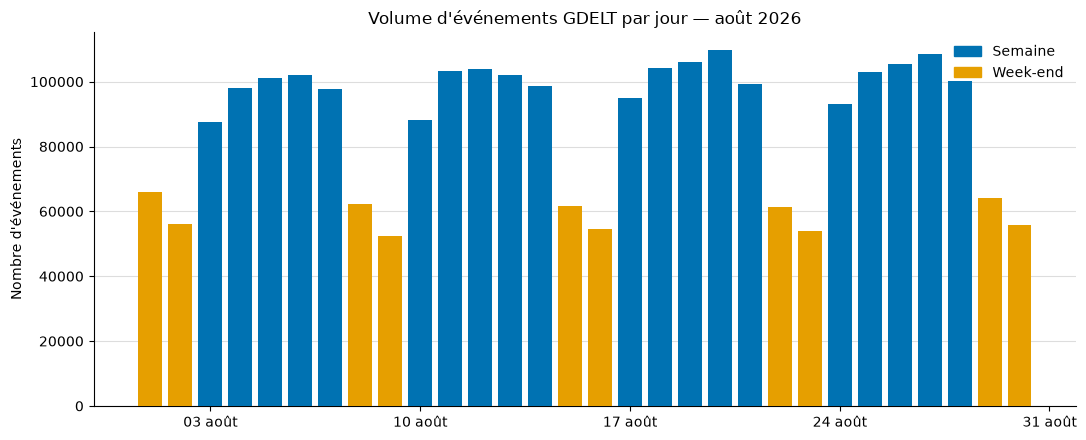

Volume moyen en week-end : 41% plus bas qu'en semaine.


In [2]:
daily = action_geo.groupby("date", as_index=False)["n_events"].sum().sort_values("date")
daily["weekend"] = daily["date"].dt.dayofweek >= 5

WEEKDAY_COLOR = "#0072B2"
WEEKEND_COLOR = "#E69F00"
bar_colors = daily["weekend"].map({False: WEEKDAY_COLOR, True: WEEKEND_COLOR})

FR_MONTHS_ABBR = {
    1: "janv.", 2: "févr.", 3: "mars", 4: "avr.", 5: "mai", 6: "juin",
    7: "juil.", 8: "août", 9: "sept.", 10: "oct.", 11: "nov.", 12: "déc.",
}

def french_date(x, pos=None):
    d = mdates.num2date(x)
    return f"{d.day:02d} {FR_MONTHS_ABBR[d.month]}"

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(daily["date"], daily["n_events"], color=bar_colors, width=0.8, zorder=3)
ax.set_axisbelow(True)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Volume d'événements GDELT par jour — août 2026")
ax.set_ylabel("Nombre d'événements")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(french_date))
handles = [
    plt.Rectangle((0, 0), 1, 1, color=WEEKDAY_COLOR, label="Semaine"),
    plt.Rectangle((0, 0), 1, 1, color=WEEKEND_COLOR, label="Week-end"),
]
ax.legend(handles=handles, frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

weekend_drop = 1 - daily.groupby("weekend")["n_events"].mean()[True] / daily.groupby("weekend")["n_events"].mean()[False]
print(f"Volume moyen en week-end : {weekend_drop:.0%} plus bas qu'en semaine.")

## 2. Top 15 pays par nombre d'événements

Même agrégat, sommé cette fois par pays sur les 30 jours. Échelle linéaire :
un bar chart encode la quantité par la longueur de la barre, et une échelle
log casse cette proportionnalité (deux barres de longueurs proches peuvent
alors représenter des quantités très différentes). Ce n'est pas un choix
esthétique mais une contrainte de lecture du graphique — le log serait
fautif ici, quel que soit l'écart entre le premier pays
(`ActionGeo_CountryCode`, référentiel FIPS) et les suivants. Les
États-Unis écrasent effectivement le reste : c'est le résultat, pas un
artefact d'échelle à corriger.

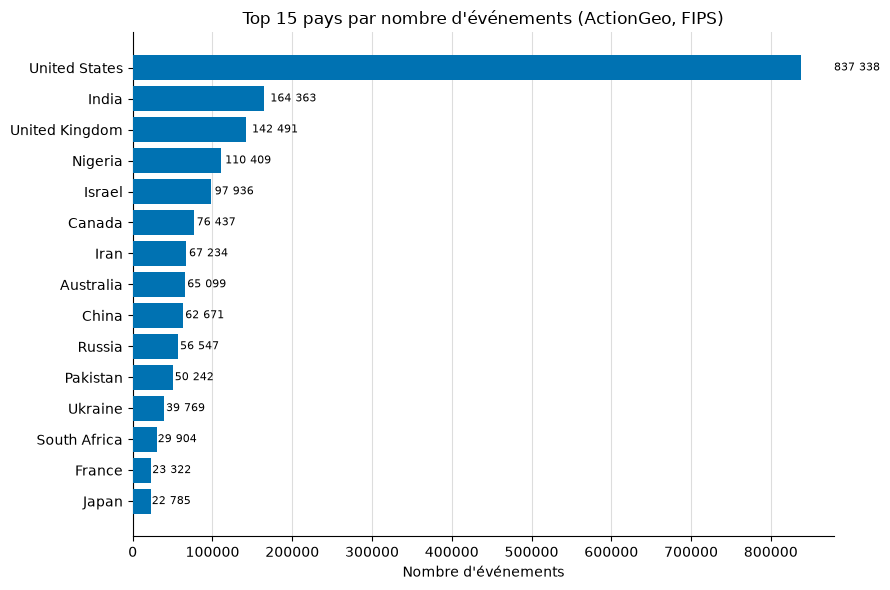

In [3]:
by_country = (
    action_geo.groupby(["ActionGeo_CountryCode", "country_name"], observed=True)["n_events"]
    .sum()
    .reset_index()
    .sort_values("n_events", ascending=False)
)
top15_geo = by_country.head(15)

plot_order = top15_geo.sort_values("n_events")  # ascending : le plus grand en haut du barh
y_pos = np.arange(len(plot_order))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y_pos, plot_order["n_events"], color="#0072B2", zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_order["country_name"])
ax.set_xlabel("Nombre d'événements")
ax.set_title("Top 15 pays par nombre d'événements (ActionGeo, FIPS)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for y, v in zip(y_pos, plot_order["n_events"]):
    ax.text(v * 1.05, y, f"{v:,}".replace(",", " "), va="center", fontsize=8)
fig.tight_layout()
plt.show()

## 3. Ratio conflit / coopération par pays

QuadClass classe chaque événement en 4 catégories : coopération verbale (1),
coopération matérielle (2), conflit verbal (3), conflit matériel (4). Le
ratio retenu est `(conflit verbal + matériel) / (coopération verbale +
matérielle)` par pays.

Le top 15 est le même ensemble de pays qu'à la figure 2 (par volume), pas un
nouveau top 15 par ratio : sur un pays à faible volume, un ratio peut être
extrême sans être significatif (quelques événements suffisent à le faire
varier). Rester sur les pays à fort volume garde le ratio lisible et
comparable à la figure précédente. Une ligne à 1 marque la parité
conflit/coopération, pour situer chaque pays par rapport à ce repère plutôt
que seulement les uns par rapport aux autres.

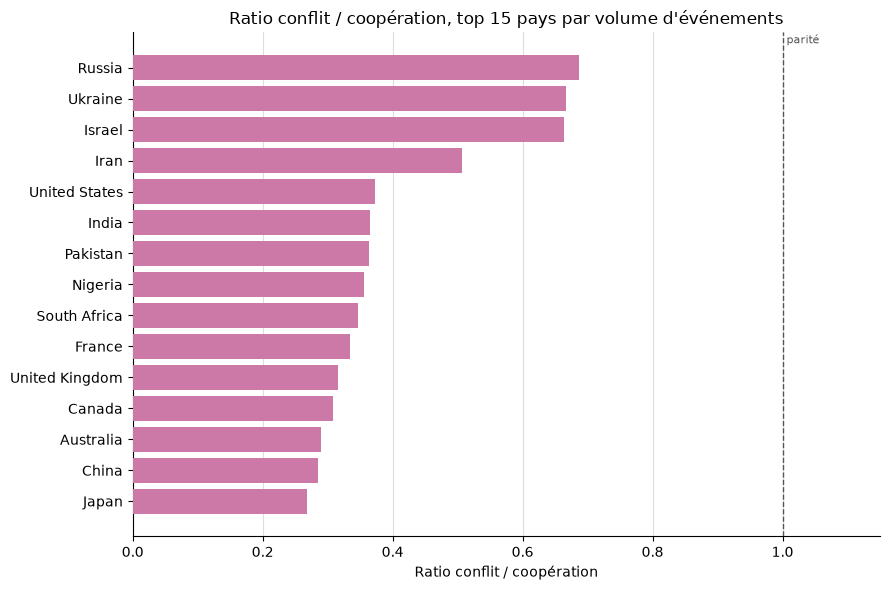

In [4]:
quad = (
    action_geo.groupby(["ActionGeo_CountryCode", "country_name"], observed=True)
    .agg(
        n_verbal_cooperation=("n_verbal_cooperation", "sum"),
        n_material_cooperation=("n_material_cooperation", "sum"),
        n_verbal_conflict=("n_verbal_conflict", "sum"),
        n_material_conflict=("n_material_conflict", "sum"),
    )
    .reset_index()
)
quad["cooperation"] = quad["n_verbal_cooperation"] + quad["n_material_cooperation"]
quad["conflict"] = quad["n_verbal_conflict"] + quad["n_material_conflict"]
quad["ratio"] = quad["conflict"] / quad["cooperation"]

top15_codes = set(top15_geo["ActionGeo_CountryCode"])
quad_top15 = quad[quad["ActionGeo_CountryCode"].isin(top15_codes)].sort_values("ratio")

y_pos = np.arange(len(quad_top15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y_pos, quad_top15["ratio"], color="#CC79A7", zorder=3)
ax.axvline(1.0, color="#555555", linestyle="--", linewidth=1, zorder=4)
ax.text(1.0, len(quad_top15) - 0.3, " parité", color="#555555", fontsize=8, va="bottom")
ax.set_yticks(y_pos)
ax.set_yticklabels(quad_top15["country_name"])
ax.set_xlabel("Ratio conflit / coopération")
ax.set_title("Ratio conflit / coopération, top 15 pays par volume d'événements")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, max(1.15, quad_top15["ratio"].max() * 1.15))
fig.tight_layout()
plt.show()

## 4. Top 15 paires d'acteurs entre pays différents

`actor_interactions` associe déjà chaque paire `(Actor1CountryCode,
Actor2CountryCode)` à son nombre d'événements et sa tonalité moyenne
(`AvgTone`, référentiel CAMEO, filtré `entity_type == "pays"` des deux côtés
par `transform.py`). Les codes sont traduits en noms via
`CAMEO_COUNTRY_TYPES` pour rester lisibles.

Une paire où `Actor1CountryCode == Actor2CountryCode` est domestique : un
acteur national envers un autre acteur du même pays (ex. USA → USA), pas une
erreur de jointure. Mais l'axe de cette figure vise les interactions *entre*
pays acteurs, et ces paires dominent le classement brut au point d'écraser
les interactions internationales. Mesuré sur les données : elles
représentent **27,2 % des événements** du corpus `actor_interactions` (186
paires sur 9595) — un résultat à part entière, pas un déchet qu'on retire
sans le dire. Cette figure les exclut ; le calcul de leur part se fait sur le
corpus complet, avant tout tri, pour ne pas biaiser le chiffre annoncé.

Une fois les paires domestiques exclues, la composition du top 15 change, et
avec elle son profil de tonalité. Mesuré sur les données : 14 des 15 paires
internationales les plus fréquentes ont une tonalité négative, mais une
(Pakistan → Arabie saoudite) est légèrement positive (+0,18), pour un
ensemble allant de -5,14 à +0,18. Le constat qui justifiait l'échelle
séquentielle utilisée précédemment (toutes négatives) ne tient donc plus une
fois le filtre domestique appliqué : la moitié « coopératif » de l'échelle a
maintenant un usage réel, même minoritaire. La figure revient à une échelle
divergente centrée sur 0 (`TwoSlopeNorm`, qui gère l'asymétrie entre les deux
bornes), rouge pour le conflictuel et bleu pour le coopératif.

Paires domestiques (Actor1 == Actor2) : 186 paires, 27.2% des événements du corpus filtré.
Tonalité du top 15 international : 1/15 paires positives, de -5.14 à 0.18.


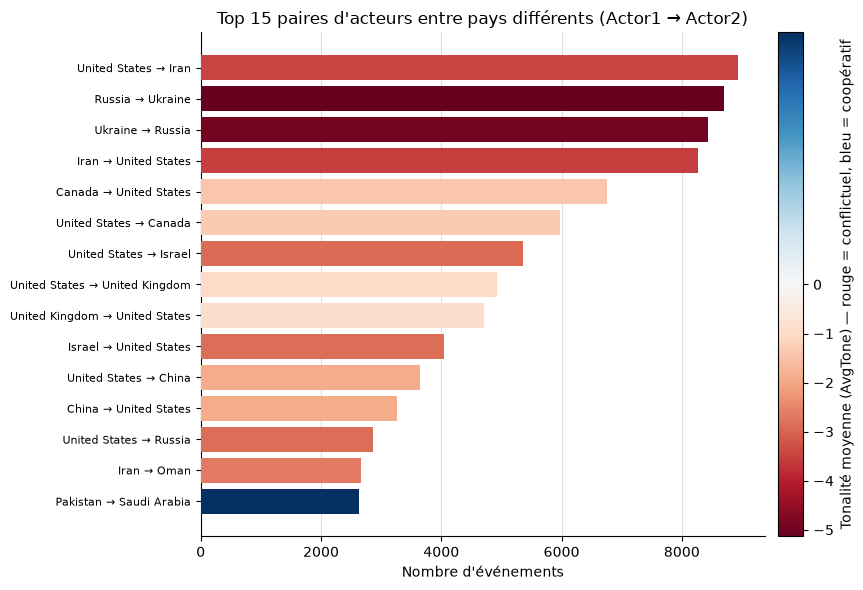

In [5]:
def country_name(code: str) -> str:
    return CAMEO_COUNTRY_TYPES.get(code, (code, None))[0]


is_domestic = actor_interactions["Actor1CountryCode"] == actor_interactions["Actor2CountryCode"]
domestic_share = actor_interactions.loc[is_domestic, "n_events"].sum() / actor_interactions["n_events"].sum()
print(f"Paires domestiques (Actor1 == Actor2) : {int(is_domestic.sum())} paires, "
      f"{domestic_share:.1%} des événements du corpus filtré.")

actor_interactions_intl = actor_interactions.loc[~is_domestic]

top15_pairs = actor_interactions_intl.sort_values("n_events", ascending=False).head(15).copy()
top15_pairs["label"] = (
    top15_pairs["Actor1CountryCode"].map(country_name)
    + " → "
    + top15_pairs["Actor2CountryCode"].map(country_name)
)
top15_pairs = top15_pairs.sort_values("n_events")  # ascending : le plus fréquent en haut du barh

n_positive = (top15_pairs["avg_tone"] > 0).sum()
print(f"Tonalité du top 15 international : {n_positive}/{len(top15_pairs)} paires positives, "
      f"de {top15_pairs['avg_tone'].min():.2f} à {top15_pairs['avg_tone'].max():.2f}.")

# Plus uniformément négatif une fois les paires domestiques exclues (voir mesure
# ci-dessus) : la moitié "coopératif" de l'échelle a un usage réel, même
# minoritaire. Échelle divergente centrée sur 0, TwoSlopeNorm gère l'asymétrie
# entre les deux bornes.
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=top15_pairs["avg_tone"].min(), vmax=top15_pairs["avg_tone"].max())
cmap = plt.cm.RdBu
colors = cmap(norm(top15_pairs["avg_tone"]))

y_pos = np.arange(len(top15_pairs))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y_pos, top15_pairs["n_events"], color=colors, zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15_pairs["label"], fontsize=8)
ax.set_xlabel("Nombre d'événements")
ax.set_title("Top 15 paires d'acteurs entre pays différents (Actor1 → Actor2)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Tonalité moyenne (AvgTone) — rouge = conflictuel, bleu = coopératif")

fig.tight_layout()
plt.show()